# STAP Barcode Pipeline Result Analysis

This notebook analyzes the barcode-first STAP oligo pipeline output. It compares the oligo identity inferred from the R3 barcode against the Bowtie2 aligned reference sequence, estimates how many deduplicated read1 TSS events are misaligned, and plots methylation-state counts for five oligos after removing those misaligned reads.

## 1. Packages To Install

Install these in the environment you use to launch Jupyter:

```bash
mamba install -c conda-forge -c bioconda jupyterlab pandas numpy matplotlib seaborn pysam
```

This notebook reads TSV files and BAM files, so it does not need `openpyxl`.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import pysam
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

## Input Paths

The defaults point at the full oligo500 barcode-pipeline output. Edit `SAMPLE` or `RESULT_DIR` if you want to analyze a different run.

In [2]:
SAMPLE = "STAP_TSS_6_oligos_S1"

repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent

RESULT_DIR = repo / "results" / "barcode_pipeline" / SAMPLE
BAM = RESULT_DIR / f"{SAMPLE}.bowtie2.dedup.bam"
OLIGO_METADATA = RESULT_DIR / f"{SAMPLE}.oligo_metadata.tsv"
DEMUX_STATS = RESULT_DIR / f"{SAMPLE}.demux.stats.tsv"
TSS_TABLE = RESULT_DIR / f"{SAMPLE}.tss_by_oligo_meth.tsv"

for path in [RESULT_DIR, BAM, OLIGO_METADATA, DEMUX_STATS, TSS_TABLE]:
    print(path, "OK" if path.exists() else "MISSING")

/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_6_oligos_S1 OK
/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_6_oligos_S1/STAP_TSS_6_oligos_S1.bowtie2.dedup.bam OK
/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_6_oligos_S1/STAP_TSS_6_oligos_S1.oligo_metadata.tsv OK
/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_6_oligos_S1/STAP_TSS_6_oligos_S1.demux.stats.tsv OK
/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_6_oligos_S1/STAP_TSS_6_oligos_S1.tss_by_oligo_meth.tsv OK


## Load Run Summaries

`oligo_metadata.tsv` is generated in the same order used to build the 500-oligo reference FASTA. For `data_6.fa`, we match the last 10 bp to the barcode table. We use this to define the expected aligned reference for each barcode-derived `OLIGO=` tag.

In [3]:
demux_stats = pd.read_csv(DEMUX_STATS, sep="\t")
display(demux_stats)

,metric,count
0,oligo_records_loaded,500
1,barcode_mismatches_0,31767295
2,barcode_mismatches_1,422745
3,barcode_offset_0,32190040
4,barcode_orientation_forward,4252
...,...,...
68,meth_TAG_10%,5767165
69,meth_TGA_20%,3828035
70,meth_TTT_100%,1471348
71,total_triplets,35609205


In [4]:
from Bio import SeqIO

fasta_ids = []
fasta_barcodes = []
for record in SeqIO.parse("/gpfs/data/zhou-lab/dcai/059_DT/1_meCpG_STAP/data_6/data_6.fa", "fasta"):
    fasta_ids.append(record.id)
    fasta_barcodes.append(str(record.seq[-10:]))
fasta_meta = pd.DataFrame(
    {
    'fasta_id': fasta_ids,
    'fasta_barcode': fasta_barcodes
    }
)

In [5]:
oligo_meta = pd.read_csv(OLIGO_METADATA, sep="\t", dtype=str).fillna("")
oligo_meta = pd.merge(fasta_meta, oligo_meta, how='left', left_on='fasta_barcode', right_on='barcode')
oligo_meta.rename(columns={'fasta_id': 'expected_chrom'}, inplace=True)
oligo_to_chrom = dict(zip(oligo_meta["oligo_id"], oligo_meta["expected_chrom"]))
display(oligo_meta[["oligo_id", "barcode", "expected_chrom"]].head())

,oligo_id,barcode,expected_chrom
0,NativeTSS:3675:CACACCATGC,CACACCATGC,pSTAP_Test1
1,NativeTSS:3675:GATTAACCGC,GATTAACCGC,pSTAP_Test2
2,NativeTSS:2416:CCTTGACTGG,CCTTGACTGG,pSTAP_Test3
3,NativeTSS:2416:CTCTTGGTGT,CTCTTGGTGT,pSTAP_Test4
4,NativeTSS:1613:TCGGGCGAGA,TCGGGCGAGA,pSTAP_Test5


## 2. Misalignment From Barcode Identity Versus Aligned Sequence

A read is called **aligned_to_barcode_oligo** when the BAM reference name matches the expected `seqN` for the `OLIGO=` tag in the read name. It is called **misaligned_to_other_oligo** when the barcode says one oligo but Bowtie2 places read1 on another oligo sequence.

This section uses deduplicated primary read1 alignments, because those are the reads used for TSS quantification.

In [6]:
METH_RE = re.compile(r"(?:^|\|)METH=([^|]+)")
OLIGO_UMI_RE = re.compile(r"\|OLIGO=(.+)_([ACGTNacgtn]{22})$")

def parse_query_name(query_name):
    meth_match = METH_RE.search(query_name)
    oligo_match = OLIGO_UMI_RE.search(query_name)
    meth = meth_match.group(1) if meth_match else "UNKNOWN"
    oligo = oligo_match.group(1) if oligo_match else "UNKNOWN"
    umi = oligo_match.group(2).upper() if oligo_match else "UNKNOWN"
    return oligo, meth, umi

def read1_tss_1based(read):
    return int(read.reference_end) if read.is_reverse else int(read.reference_start) + 1

rows = []
with pysam.AlignmentFile(BAM, "rb") as bam:
    for read in bam.fetch(until_eof=True):
        if not read.is_read1:
            continue
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if read.is_qcfail or read.is_duplicate:
            continue
        oligo, meth, umi = parse_query_name(read.query_name)
        aligned_chrom = bam.get_reference_name(read.reference_id)
        expected_chrom = oligo_to_chrom.get(oligo, "UNKNOWN")
        if expected_chrom == "UNKNOWN":
            status = "unknown_oligo_tag"
        elif aligned_chrom == expected_chrom:
            status = "aligned_to_barcode_oligo"
        else:
            status = "misaligned_to_other_oligo"
        rows.append({
            "read_name": read.query_name,
            "oligo_id": oligo,
            "meth_state": meth,
            "umi": umi,
            "expected_chrom": expected_chrom,
            "aligned_chrom": aligned_chrom,
            "tss_position": read1_tss_1based(read),
            "mapq": read.mapping_quality,
            "is_reverse": read.is_reverse,
            "status": status,
        })

read1_df = pd.DataFrame(rows)
print(f"Deduplicated primary mapped read1 records: {len(read1_df):,}")
display(read1_df.head())

Deduplicated primary mapped read1 records: 5,906,048


,read_name,oligo_id,meth_state,umi,expected_chrom,aligned_chrom,tss_position,mapq,is_reverse,status
0,VH01570:206:AAJ2NL3M5:1:2204:24650:49219|METH=1%|OLIGO=NativeTSS:3675:CACACCATGC_CTTATCCTATGGTGTTGAAGAA,NativeTSS:3675:CACACCATGC,1%,CTTATCCTATGGTGTTGAAGAA,pSTAP_Test1,pSTAP_Test1,2,42,False,aligned_to_barcode_oligo
1,VH01570:206:AAJ2NL3M5:1:1506:24272:10712|METH=1%|OLIGO=NativeTSS:3675:CACACCATGC_GACAAGTGGAATTGGTGTTGGG,NativeTSS:3675:CACACCATGC,1%,GACAAGTGGAATTGGTGTTGGG,pSTAP_Test1,pSTAP_Test1,5,42,False,aligned_to_barcode_oligo
2,VH01570:206:AAJ2NL3M5:1:2307:25692:43862|METH=0%|OLIGO=NativeTSS:2416:CCTTGACTGG_GCCATAAGTTAGTGGGATAGTA,NativeTSS:2416:CCTTGACTGG,0%,GCCATAAGTTAGTGGGATAGTA,pSTAP_Test3,pSTAP_Test1,7,1,False,misaligned_to_other_oligo
3,VH01570:206:AAJ2NL3M5:1:2402:61328:5165|METH=100%|OLIGO=NativeTSS:2416:CCTTGACTGG_TTGCACATGGGAAGGATAGGGG,NativeTSS:2416:CCTTGACTGG,100%,TTGCACATGGGAAGGATAGGGG,pSTAP_Test3,pSTAP_Test1,59,1,True,misaligned_to_other_oligo
4,VH01570:206:AAJ2NL3M5:1:2605:61688:33885|METH=10%|OLIGO=NativeTSS:2416:CTCTTGGTGT_CCTTTTATGAATGGAGTTTGAG,NativeTSS:2416:CTCTTGGTGT,10%,CCTTTTATGAATGGAGTTTGAG,pSTAP_Test4,pSTAP_Test1,60,1,True,misaligned_to_other_oligo


In [7]:
status_summary = (
    read1_df.groupby("status")
    .size()
    .rename("reads")
    .reset_index()
    .assign(frac=lambda d: d["reads"] / d["reads"].sum())
    .sort_values("reads", ascending=False)
)
display(status_summary)

misaligned_df = read1_df.query("status == 'misaligned_to_other_oligo'").copy()
print(f"Misaligned read1 records: {len(misaligned_df):,}")
print(f"Misaligned fraction: {len(misaligned_df) / max(len(read1_df), 1):.2%}")

,status,reads,frac
0,aligned_to_barcode_oligo,5878612,0.995355
1,misaligned_to_other_oligo,26507,0.004488
2,unknown_oligo_tag,929,0.000157


Misaligned read1 records: 26,507
Misaligned fraction: 0.45%


In [8]:
mis_by_meth = (
    read1_df.assign(is_misaligned=read1_df["status"].eq("misaligned_to_other_oligo"))
    .groupby("meth_state")
    .agg(total_reads=("read_name", "size"), misaligned_reads=("is_misaligned", "sum"))
    .assign(misaligned_frac=lambda d: d["misaligned_reads"] / d["total_reads"])
    .sort_index()
)
display(mis_by_meth)

top_misalignment_pairs = (
    misaligned_df.groupby(["oligo_id", "expected_chrom", "aligned_chrom"])
    .size()
    .rename("reads")
    .reset_index()
    .sort_values("reads", ascending=False)
    .head(20)
)
display(top_misalignment_pairs)

,total_reads,misaligned_reads,misaligned_frac
meth_state,,,
0%,1037848,4311,0.004154
0.1%,887481,3769,0.004247
1%,1227136,5102,0.004158
10%,992464,4420,0.004454
100%,295651,1575,0.005327
20%,728321,3341,0.004587
40%,412231,2123,0.005150
60%,324916,1866,0.005743


,oligo_id,expected_chrom,aligned_chrom,reads
11,NativeTSS:2416:CCTTGACTGG,pSTAP_Test3,pSTAP_Test4,16662
16,NativeTSS:2416:CTCTTGGTGT,pSTAP_Test4,pSTAP_Test3,4482
8,NativeTSS:1613:TCGGGCGAGA,pSTAP_Test5,pSTAP_Test6,949
27,NativeTSS:3675:GATTAACCGC,pSTAP_Test2,pSTAP_Test5,353
17,NativeTSS:2416:CTCTTGGTGT,pSTAP_Test4,pSTAP_Test5,334
21,NativeTSS:3675:CACACCATGC,pSTAP_Test1,pSTAP_Test4,326
7,NativeTSS:1613:TCGGGCGAGA,pSTAP_Test5,pSTAP_Test4,313
6,NativeTSS:1613:TCGGGCGAGA,pSTAP_Test5,pSTAP_Test3,306
28,NativeTSS:3675:GATTAACCGC,pSTAP_Test2,pSTAP_Test6,301
20,NativeTSS:3675:CACACCATGC,pSTAP_Test1,pSTAP_Test3,287


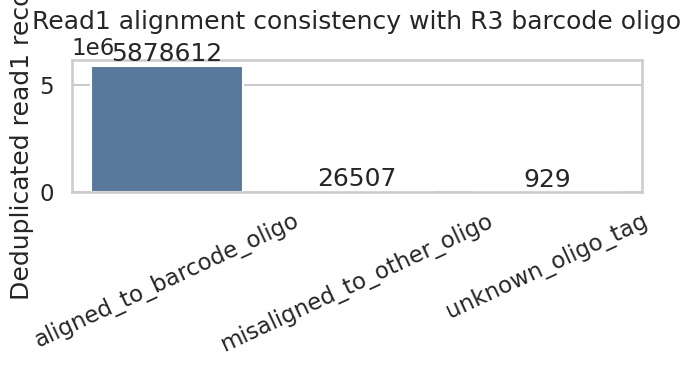

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_status = status_summary.copy()
sns.barplot(data=plot_status, x="status", y="reads", ax=ax, color="#4C78A8")
ax.set_xlabel("")
ax.set_ylabel("Deduplicated read1 records")
ax.set_title("Read1 alignment consistency with R3 barcode oligo")
ax.tick_params(axis="x", rotation=25)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()

## 3. 6-Oligo Methylation Counts After Removing Misaligned Reads

The next cells discard reads where the aligned reference sequence disagrees with the barcode-derived oligo. By default, the notebook selects the five oligos with the most remaining read1 records. You can replace `selected_oligos` with any five `oligo_id` values.

In [11]:
aligned_only = read1_df.query("status == 'aligned_to_barcode_oligo'").copy()

# Set this manually if desired, e.g.:
# selected_oligos = ["NativeTSS:2355:GCCCATGCAG", "NativeTSS:2355:ACGCGGATTG", ...]
selected_oligos = (
    aligned_only.groupby("oligo_id")
    .size()
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
)

print("Selected oligos:")
for oligo in selected_oligos:
    print("  ", oligo)

meth_order = ["0%", "0.1%", "1%", "10%", "20%", "40%", "60%", "100%"]
selected_df = aligned_only[aligned_only["oligo_id"].isin(selected_oligos)].copy()

counts = (
    selected_df.groupby(["oligo_id", "meth_state"])
    .size()
    .rename("Count")
    .reset_index()
)
full_index = pd.MultiIndex.from_product([selected_oligos, meth_order], names=["oligo_id", "meth_state"])
counts = (
    counts.set_index(["oligo_id", "meth_state"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)
display(counts.head(20))

Selected oligos:
   NativeTSS:1613:TCGGGCGAGA
   NativeTSS:2416:CCTTGACTGG
   NativeTSS:2416:CTCTTGGTGT
   NativeTSS:3675:CACACCATGC
   NativeTSS:3675:GATTAACCGC
   NativeTSS:1613:GACGTCAAAT


,oligo_id,meth_state,Count
0,NativeTSS:1613:TCGGGCGAGA,0%,444210
1,NativeTSS:1613:TCGGGCGAGA,0.1%,377962
2,NativeTSS:1613:TCGGGCGAGA,1%,509303
3,NativeTSS:1613:TCGGGCGAGA,10%,397554
4,NativeTSS:1613:TCGGGCGAGA,20%,293031
5,NativeTSS:1613:TCGGGCGAGA,40%,143598
6,NativeTSS:1613:TCGGGCGAGA,60%,104715
7,NativeTSS:1613:TCGGGCGAGA,100%,102822
8,NativeTSS:2416:CCTTGACTGG,0%,312576
9,NativeTSS:2416:CCTTGACTGG,0.1%,267293


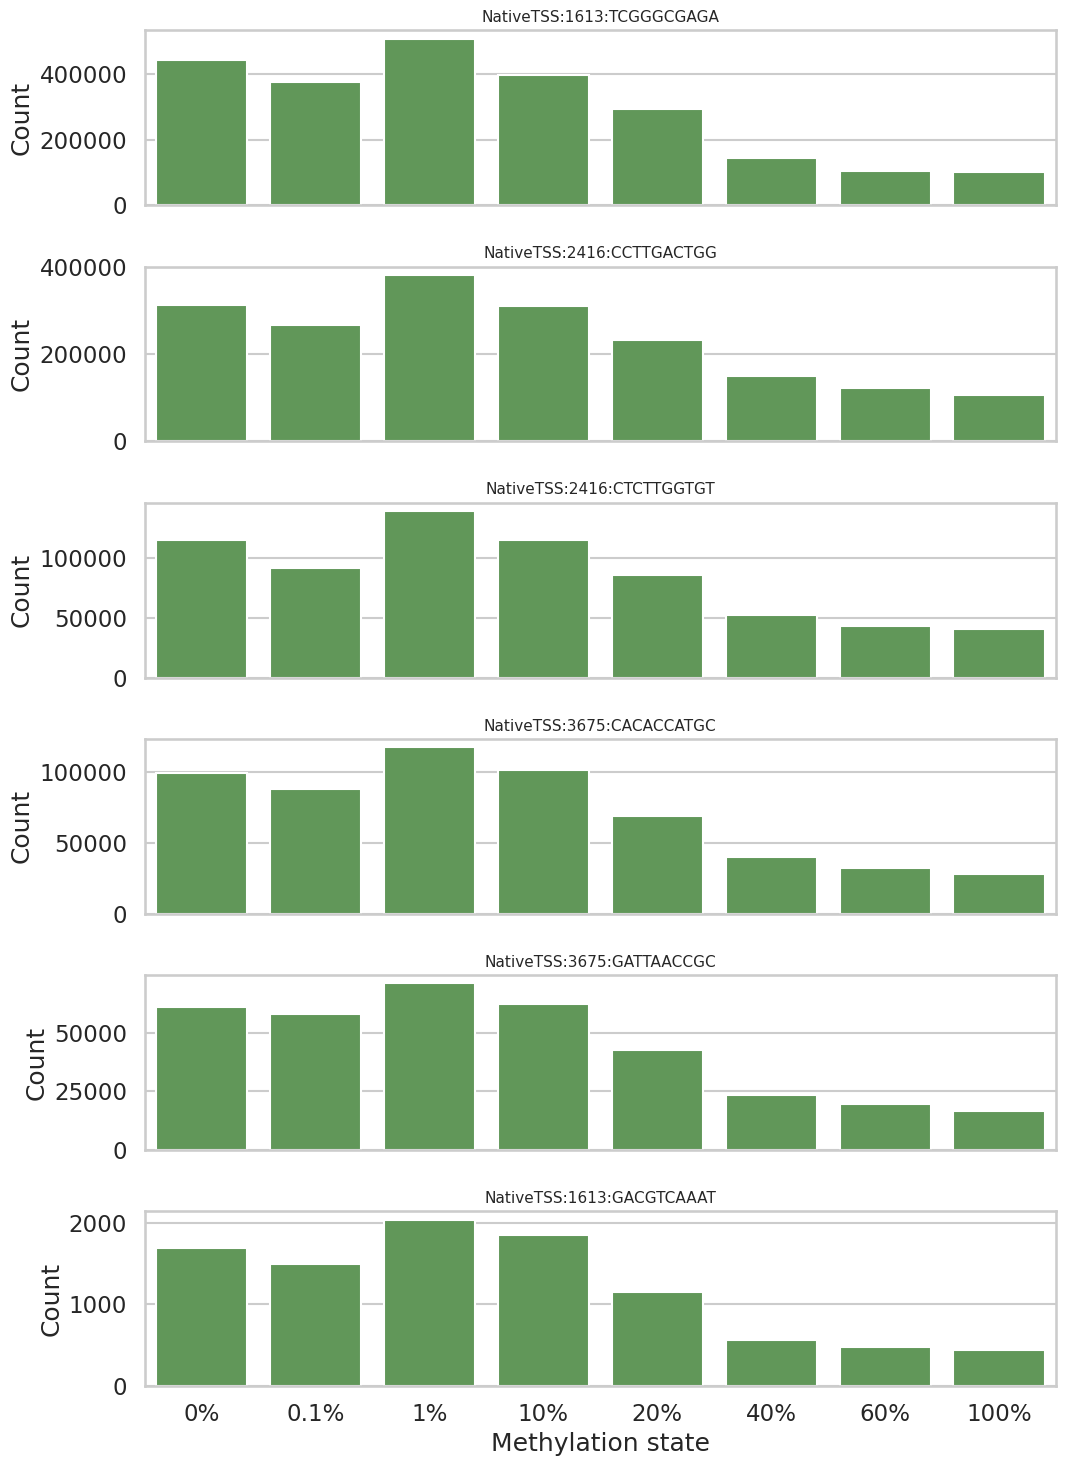

In [11]:
fig, axes = plt.subplots(len(selected_oligos), 1, figsize=(11, 2.5 * len(selected_oligos)), sharex=True)
if len(selected_oligos) == 1:
    axes = [axes]

for ax, oligo in zip(axes, selected_oligos):
    sub = counts[counts["oligo_id"] == oligo]
    sns.barplot(data=sub, x="meth_state", y="Count", order=meth_order, ax=ax, color="#59A14F")
    ax.set_title(oligo, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
plt.xlabel("Methylation state")
plt.tight_layout()

,meth_state,Count
0,0%,1033379
1,0.1%,883549
2,1%,1221848
3,10%,987891
5,20%,724871
6,40%,410039
7,60%,323002
4,100%,294033


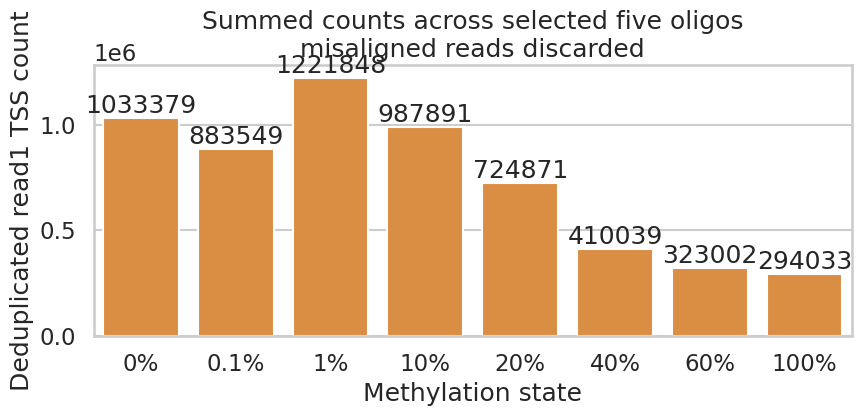

In [12]:
summed_counts = counts.groupby("meth_state", as_index=False)["Count"].sum()
summed_counts["meth_state"] = pd.Categorical(summed_counts["meth_state"], categories=meth_order, ordered=True)
summed_counts = summed_counts.sort_values("meth_state")

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=summed_counts, x="meth_state", y="Count", order=meth_order, ax=ax, color="#F28E2B")
ax.set_title("Summed counts across selected five oligos\nmisaligned reads discarded")
ax.set_xlabel("Methylation state")
ax.set_ylabel("Deduplicated read1 TSS count")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()
display(summed_counts)

## Optional: Save Aligned-Only TSS Counts

This writes a filtered table with the same main columns as the pipeline final output, but after removing barcode/alignment disagreements.

In [14]:
SAVE_FILTERED_COUNTS = True

filtered_tss_counts = (
    aligned_only.groupby(["oligo_id", "meth_state", "aligned_chrom", "tss_position"])
    .size()
    .rename("Count")
    .reset_index()
    .rename(columns={
        "oligo_id": "Oligo_ID",
        "meth_state": "Meth_State",
        "aligned_chrom": "Chromosome",
        "tss_position": "TSS_Position",
    })
)

display(filtered_tss_counts.head())

if SAVE_FILTERED_COUNTS:
    out_path = RESULT_DIR / f"{SAMPLE}.tss_by_oligo_meth.aligned_only.tsv"
    filtered_tss_counts.to_csv(out_path, sep="\t", index=False)
    print(out_path)

,Oligo_ID,Meth_State,Chromosome,TSS_Position,Count
0,NativeTSS:1613:GACGTCAAAT,0%,pSTAP_Test6,66,1
1,NativeTSS:1613:GACGTCAAAT,0%,pSTAP_Test6,133,1
2,NativeTSS:1613:GACGTCAAAT,0%,pSTAP_Test6,136,1
3,NativeTSS:1613:GACGTCAAAT,0%,pSTAP_Test6,146,1
4,NativeTSS:1613:GACGTCAAAT,0%,pSTAP_Test6,153,13


/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_6_oligos_S1/STAP_TSS_6_oligos_S1.tss_by_oligo_meth.aligned_only.tsv


In [23]:
filtered_tss_counts_agg = filtered_tss_counts.groupby(["Oligo_ID", "Meth_State"], as_index=False)['Count'].agg('sum')
filtered_tss_counts_agg.head()

,Oligo_ID,Meth_State,Count
0,NativeTSS:1613:GACGTCAAAT,0%,1693
1,NativeTSS:1613:GACGTCAAAT,0.1%,1492
2,NativeTSS:1613:GACGTCAAAT,1%,2041
3,NativeTSS:1613:GACGTCAAAT,10%,1853
4,NativeTSS:1613:GACGTCAAAT,100%,444


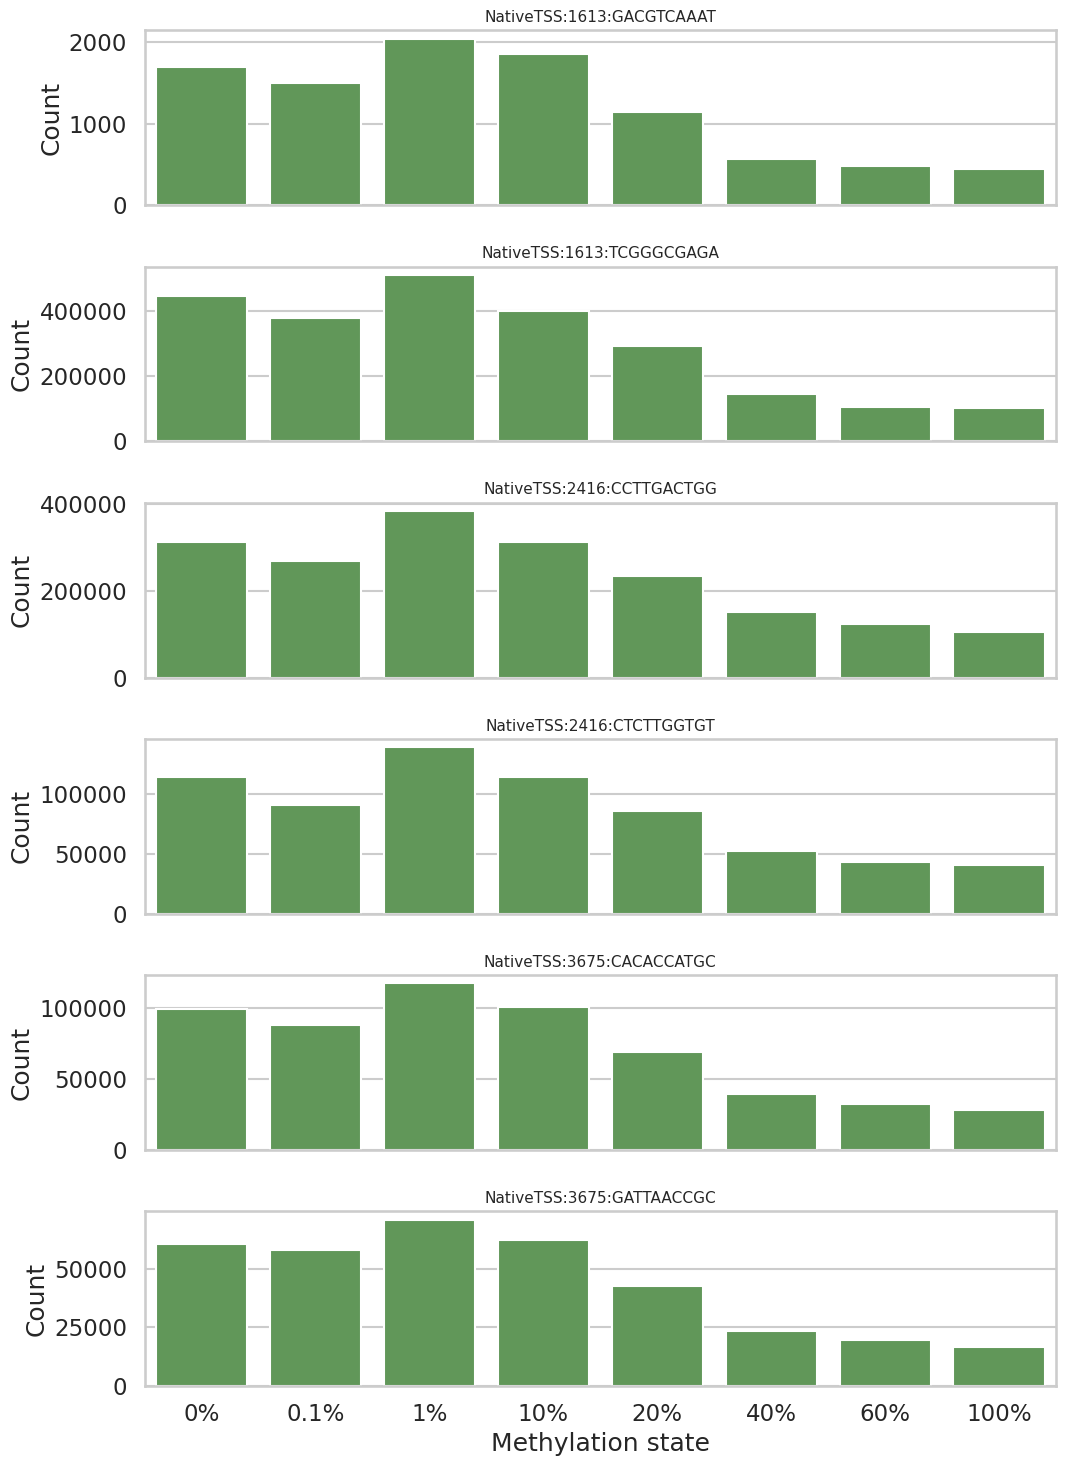

In [26]:
selected_oligos = pd.unique(filtered_tss_counts_agg['Oligo_ID'])
fig, axes = plt.subplots(len(selected_oligos), 1, figsize=(11, 2.5 * len(selected_oligos)), sharex=True)
if len(selected_oligos) == 1:
    axes = [axes]

for ax, oligo in zip(axes, selected_oligos):
    sub = filtered_tss_counts_agg[filtered_tss_counts_agg["Oligo_ID"] == oligo]
    sns.barplot(data=sub, x="Meth_State", y="Count", order=meth_order, ax=ax, color="#59A14F")
    ax.set_title(oligo, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
plt.xlabel("Methylation state")
plt.tight_layout()